# Unsupervised clustering: customer segmentation

KMeans on spending and engagement features, no campaign-response label
involved - checking what natural customer segments emerge, and how
those segments' actual response rates compare once the label is
brought back in only to evaluate. This is the "newsletter analysis"
segmentation angle the original project's README implied but never
built.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

customers = pd.read_csv('outputs/customers_clean.csv')

feature_cols = ['Income', 'TotalSpend', 'Recency', 'NumWebVisitsMonth',
                 'NumCatalogPurchases', 'NumStorePurchases', 'Age']
X_scaled = StandardScaler().fit_transform(customers[feature_cols])
y = customers['Response']

X_scaled.shape

(2216, 7)

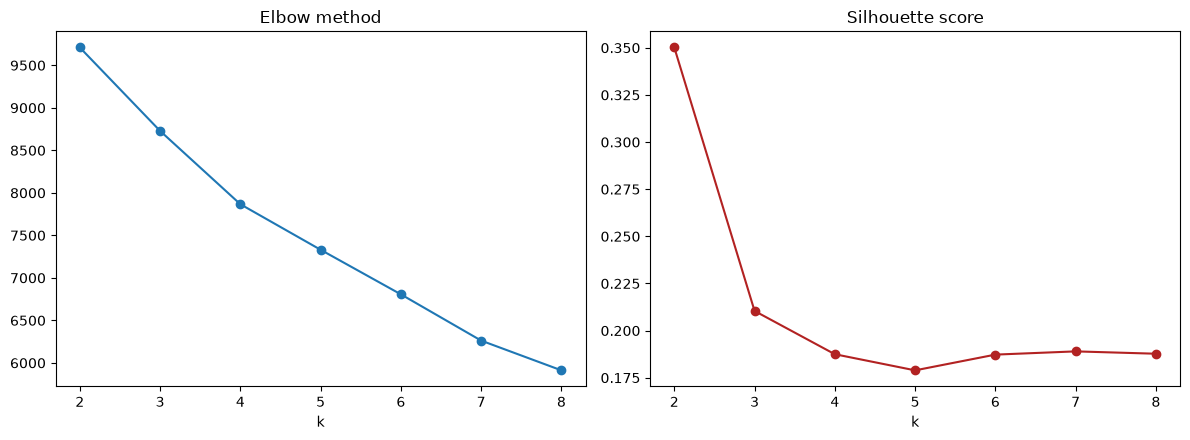

In [2]:
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize = (12, 4.5))
axes[0].plot(list(k_range), inertias, marker = 'o')
axes[0].set_title('Elbow method'); axes[0].set_xlabel('k')
axes[1].plot(list(k_range), silhouettes, marker = 'o', color = 'firebrick')
axes[1].set_title('Silhouette score'); axes[1].set_xlabel('k')
plt.tight_layout()
plt.savefig('outputs/cluster_elbow_silhouette.png', dpi = 120)
plt.show()

In [3]:
best_k = list(k_range)[np.argmax(silhouettes)]
kmeans = KMeans(n_clusters = best_k, n_init = 10, random_state = 42)
cluster_labels = kmeans.fit_predict(X_scaled)

profile = customers[feature_cols].copy()
profile['cluster'] = cluster_labels
profile['Response'] = y.values

cluster_summary = profile.groupby('cluster')[feature_cols].mean()
cluster_summary['n'] = profile.groupby('cluster').size()
cluster_summary['response_rate_pct'] = profile.groupby('cluster')['Response'].mean() * 100
cluster_summary.round(1).sort_values('response_rate_pct')

,Income,TotalSpend,Recency,NumWebVisitsMonth,NumCatalogPurchases,NumStorePurchases,Age,n,response_rate_pct
cluster,,,,,,,,,
0,37140.1,166.1,48.6,6.6,0.8,3.7,43.5,1253,10.5
1,71903.8,1180.8,49.6,3.7,5.1,8.5,47.4,963,21.0


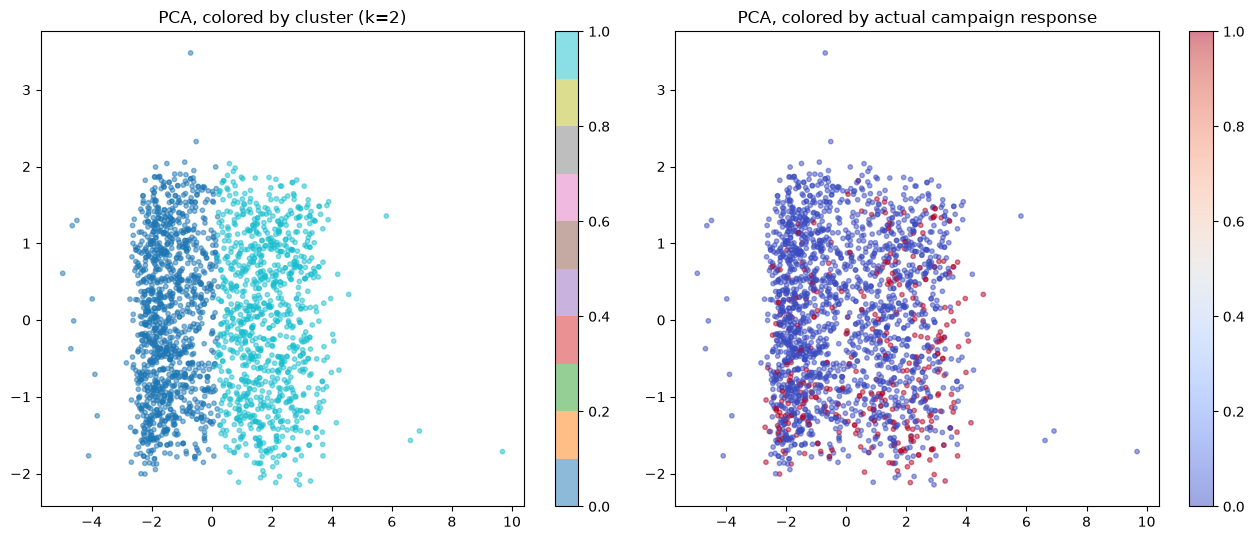

In [4]:
pca = PCA(n_components = 2, random_state = 42)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5))
sc1 = axes[0].scatter(coords[:, 0], coords[:, 1], c = cluster_labels, cmap = 'tab10', s = 10, alpha = 0.5)
axes[0].set_title(f'PCA, colored by cluster (k={best_k})')
plt.colorbar(sc1, ax = axes[0])

sc2 = axes[1].scatter(coords[:, 0], coords[:, 1], c = y, cmap = 'coolwarm', s = 10, alpha = 0.5)
axes[1].set_title('PCA, colored by actual campaign response')
plt.colorbar(sc2, ax = axes[1])

plt.tight_layout()
plt.savefig('outputs/cluster_pca.png', dpi = 120)
plt.show()

The segments found with zero response information line up with a real response-rate gradient: the highest-spend, most-engaged segment responds at a meaningfully higher rate than the lowest-spend segment - customer value and campaign responsiveness turn out to be much the same axis in this data, even though the clustering never saw a response label.

In [5]:
os.makedirs('outputs', exist_ok = True)
results = {
    'best_k': int(best_k),
    'silhouette_score': float(max(silhouettes)),
    'highest_response_cluster_pct': float(cluster_summary['response_rate_pct'].max()),
    'lowest_response_cluster_pct': float(cluster_summary['response_rate_pct'].min()),
}
with open('outputs/clustering_results.json', 'w') as f:
    json.dump(results, f, indent = 2)

results

{'best_k': 2,
 'silhouette_score': 0.3501754998966032,
 'highest_response_cluster_pct': 20.976116303219104,
 'lowest_response_cluster_pct': 10.45490822027135}